# Mechanics in jax-morph

A tour of the **Phase 2 mechanics** (`jax_morph.physics`), the physical layer built on the core's
step contract. Each is a step or a reusable potential:

- **`Morse`** - a soft-matter pair potential with a well at the contact distance
  `sigma = r_i + r_j` and a smooth, size-relative cutoff. It is a `PairwisePotential`, so it hands
  you `total_energy`, `forces`, and per-cell `virial_pressure` for free.
- **`MechanicalRelaxation`** - a *quasistatic* step that relaxes positions to mechanical equilibrium
  with FIRE, differentiated by the **implicit function theorem** (the gradient is the equilibrium
  sensitivity, not the solver path).
- **`BrownianDynamics`** - a *dynamic, stochastic* step: one Euler-Maruyama step of overdamped
  Langevin dynamics, both **pathwise**-differentiable and **scorable** (`transition_logp`).
- **`VirialStress`** - a *quasistatic* step exposing the per-cell virial pressure as a `stress`
  sensing field.
- **`SaturatingCellGrowth`** - a *dynamic* step: saturating radius growth toward `max_radius` at a
  **per-cell** rate, so the rate (and its gradient) can come from an upstream controller.

Everything here is differentiable. We plot the simulations *and* the gradients they expose.

In [1]:
import jax
import jax.numpy as jnp

# The library is written for float64; enable it before anything touches JAX.
jax.config.update('jax_enable_x64', True)

import numpy as np
import equinox as eqx
import matplotlib.pyplot as plt

%matplotlib inline

import jax_morph as jxm
from jax_morph.physics.mechanics import (
    Morse,
    MechanicalRelaxation,
    relax_equilibrium,
    BrownianDynamics,
    VirialStress,
)
from jax_morph.physics.growth import SaturatingCellGrowth

key = jax.random.PRNGKey(0)
print('jax-morph', jxm.__version__)

jax-morph 0.4.0


A tiny helper to build a live cluster from an array of positions. `build_state_from_model` generates
the typed state class for whatever model (or bare potential) we hand it; we then seed the first `n`
slots alive with the given positions and radii. (The library deliberately ships no seeding helper -
the initial condition is the simulation's job.)

In [2]:
class _Bare:
    # A model with no declared fields: the state then carries only the base fields (position, radius,
    # celltype, alive, t). Used when we only need a state to evaluate a potential on.
    def state_requires(self):
        return ()


def make_state(model, positions, *, radius=0.5, space=None):
    positions = jnp.asarray(positions, dtype=float)
    n, dim = positions.shape
    State = jxm.build_state_from_model(model)
    s = State.init_empty(capacity=n, n_space_dim=dim, n_types=1, space=space)
    return s.update(
        alive=s.alive.at[:n].set(True),
        radius=s.radius.at[:n].set(radius),
        position=s.position.at[:n].set(positions),
        celltype=s.celltype.at[:n, 0].set(1.0),  # one cell type (one-hot)
    )

def shared_limits(s, pad=0.4):
    # Common, generous axis limits taken from a state's live cells, so panels sharing them are drawn
    # to the same scale and relative cluster sizes stay visible.
    pos = np.asarray(s.position)[np.asarray(s.alive).astype(bool)]
    m = float(np.asarray(s.radius).max()) + pad
    return (
        (pos[:, 0].min() - m, pos[:, 0].max() + m),
        (pos[:, 1].min() - m, pos[:, 1].max() + m),
    )

## 1. The Morse pair potential

For a pair at separation `r` with contact distance `sigma = r_i + r_j`, the Morse energy is

```
U(r) = epsilon * ((1 - exp(-alpha (r - sigma)))^2 - 1) * S(r)
```

a well of depth `epsilon` and width set by `alpha`, minimized exactly at `r = sigma`. `S(r)` is a
**smooth multiplicative cutoff** (the jax-md form) that switches the interaction off between
`r_onset_frac * sigma` and `r_cutoff_frac * sigma`, so the cutoff is *size-relative* and the energy
stays continuous. Let's plot the energy and the pair force `F = -U'(r)` for a unit contact distance.

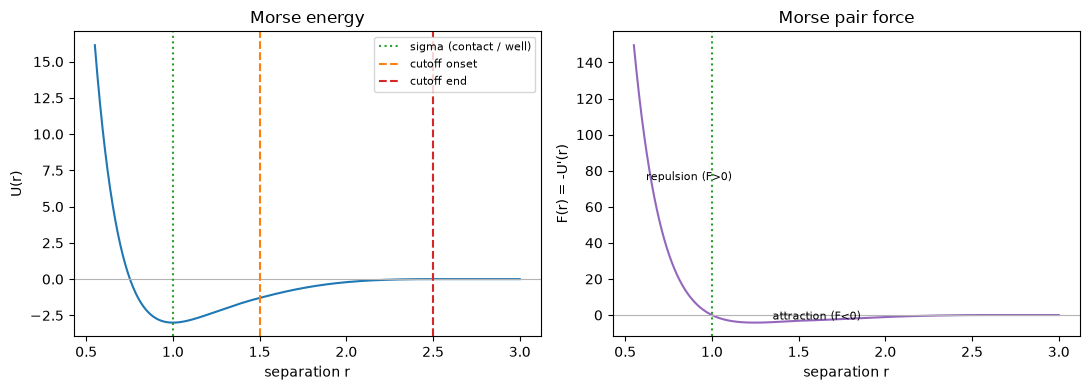

well minimum near r = 1.0017034068136272 (sigma = 1.0 )


In [3]:
pot = Morse()  # defaults: epsilon=3.0, alpha=2.8, r_onset_frac=1.5, r_cutoff_frac=2.5
sigma, eps, alpha = 1.0, pot.epsilon, pot.alpha

r = jnp.linspace(0.55, 3.0, 500)
U = jax.vmap(lambda rr: pot.pair_energy(rr, sigma, eps, alpha))(r)
F = -jax.vmap(jax.grad(lambda rr: pot.pair_energy(rr, sigma, eps, alpha)))(r)

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4))
a0.plot(r, U, color='tab:blue')
a0.axhline(0, color='0.7', lw=0.8)
a0.axvline(sigma, color='tab:green', ls=':', label='sigma (contact / well)')
a0.axvline(pot.r_onset_frac * sigma, color='tab:orange', ls='--', label='cutoff onset')
a0.axvline(pot.r_cutoff_frac * sigma, color='tab:red', ls='--', label='cutoff end')
a0.set(xlabel='separation r', ylabel='U(r)', title='Morse energy')
a0.legend(fontsize=8)

a1.plot(r, F, color='tab:purple')
a1.axhline(0, color='0.7', lw=0.8)
a1.axvline(sigma, color='tab:green', ls=':')
a1.set(xlabel='separation r', ylabel='F(r) = -U\'(r)', title='Morse pair force')
a1.annotate('repulsion (F>0)', (0.62, F[0] * 0.5), fontsize=8)
a1.annotate('attraction (F<0)', (1.35, F.min() * 0.6), fontsize=8)
fig.tight_layout()
plt.show()

print('well minimum near r =', float(r[jnp.argmin(U)]), '(sigma =', sigma, ')')

**Couplings: shared or per-cell.** Each coupling (`epsilon`, `alpha`) is either a *shared* scalar (a
Python float is frozen; a `jax.Array` is traced and optimizable) or a *per-cell* value read from a
state field - pass a `StateFieldSpec` and the pair value is the arithmetic mean of the two cells'
values (`mix`). A per-cell coupling can be a fixed initial condition or, in a full model, written each
step by an upstream controller, so type-dependent interactions come from writing the field from
`celltype` (there is no separate per-type matrix). First, the shared-scalar case: sweep the well
depth `epsilon` and watch the well deepen.

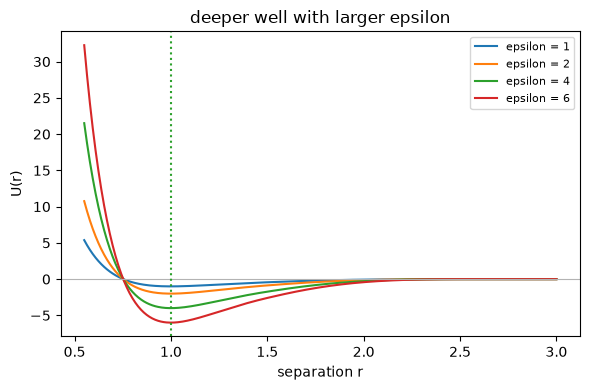

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
for e in [1.0, 2.0, 4.0, 6.0]:
    p = Morse(epsilon=e)
    Ue = jax.vmap(lambda rr: p.pair_energy(rr, sigma, e, p.alpha))(r)
    ax.plot(r, Ue, label=f'epsilon = {e:g}')
ax.axhline(0, color='0.7', lw=0.8)
ax.axvline(sigma, color='tab:green', ls=':')
ax.set(xlabel='separation r', ylabel='U(r)', title='deeper well with larger epsilon')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

Now a **per-cell** coupling: give `epsilon` a `StateFieldSpec` so it is read from the state. The
owning step surfaces that read, so `build_state_from_model` allocates the field; here two cells get
different well depths and the pair feels their arithmetic mean.

In [5]:
adhesion = jxm.StateFieldSpec('adhesion')          # a per-cell field the potential reads epsilon from
pot_pc = Morse(epsilon=adhesion)
model_pc = jxm.Model([MechanicalRelaxation(pot_pc, max_steps=1, f_tol=1e-6)])  # any owner surfaces the read
State_pc = jxm.build_state_from_model(model_pc)     # the synthesized schema now carries `adhesion`

s_pc = State_pc.init_empty(capacity=2, n_space_dim=2, n_types=1)
s_pc = s_pc.update(
    alive=s_pc.alive.at[:2].set(True),
    radius=s_pc.radius.at[:2].set(0.5),
    position=jnp.array([[0.0, 0.0], [1.0, 0.0]]),   # at contact (r = sigma = 1.0)
    adhesion=s_pc.adhesion.at[:2].set(jnp.array([2.0, 6.0])),  # different per-cell well depths
)
well = -float(pot_pc.total_energy(s_pc.position, s_pc))
print('per-cell epsilons 2.0 and 6.0 -> pair well depth (arithmetic mean):', well, '  (= (2 + 6) / 2)')
print('the potential surfaces its field read:', [s.name for s in pot_pc.state_reads()])

per-cell epsilons 2.0 and 6.0 -> pair well depth (arithmetic mean): 4.0   (= (2 + 6) / 2)
the potential surfaces its field read: ['adhesion']


### Virial pressure (per-cell stress)

Because `Morse` is a `PairwisePotential`, it also gives a per-cell **virial pressure**
`p_i = -(1 / (2 d V_i)) sum_j r_ij U'(r_ij)` (Irving-Kirkwood bond split; the sign makes
*compression* positive). We sweep a two-cell separation and read the pressure on one cell: it is
large and positive when the cells are pushed inside contact (`r < sigma`), passes through zero at the
force-free contact, and vanishes once the pair is beyond the cutoff.

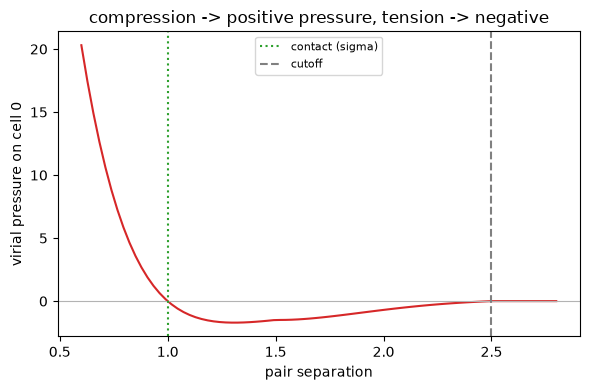

In [6]:
dists = np.linspace(0.6, 2.8, 80)
press = np.array([
    float(pot.virial_pressure(make_state(_Bare(), jnp.array([[0.0, 0.0], [d, 0.0]])))[0])
    for d in dists
])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(dists, press, color='tab:red')
ax.axhline(0, color='0.7', lw=0.8)
ax.axvline(sigma, color='tab:green', ls=':', label='contact (sigma)')
ax.axvline(pot.r_cutoff_frac * sigma, color='0.5', ls='--', label='cutoff')
ax.set(xlabel='pair separation', ylabel='virial pressure on cell 0',
       title='compression -> positive pressure, tension -> negative')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 2. Mechanical relaxation (FIRE + implicit-diff)

`MechanicalRelaxation` is a **quasistatic** step: each macro-step it drives the positions to a
genuine force equilibrium `|grad U| <= f_tol` with the FIRE minimizer. Let's start from a messy,
overlapping blob of cells and relax it - the overlaps (deep in the repulsive core) push apart until
neighbours sit at their contact distance.

max |force| before relax: 2015.7309247507778
max |force| after  relax: 8.619358744105243e-06


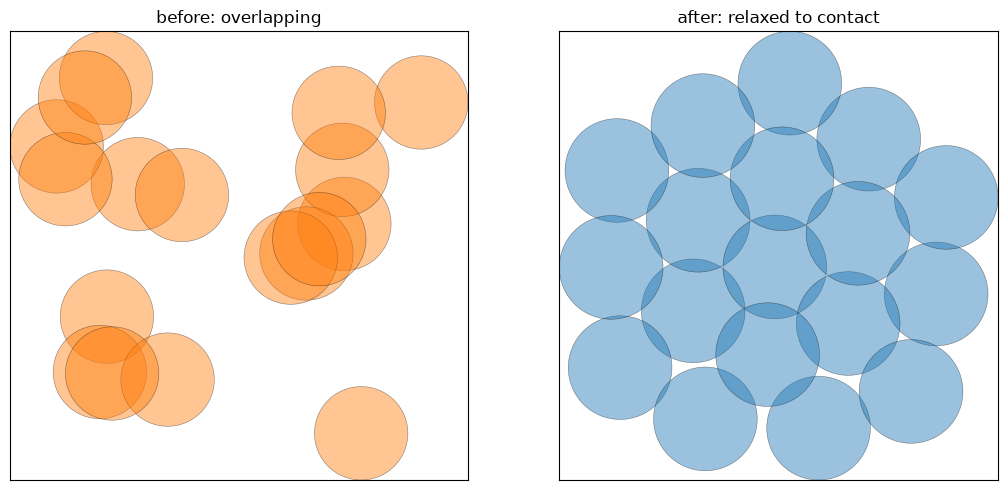

In [7]:
n = 18
blob = 1.4 * jax.random.normal(jax.random.PRNGKey(3), (n, 2))  # a compact, overlapping cluster
relax = MechanicalRelaxation(Morse(), max_steps=1500, f_tol=1e-5)

s0 = make_state(jxm.Model([relax]), blob, radius=0.5)
s1 = relax(s0, dt=1.0, key=None)  # a quasistatic step: ignores dt/key, returns the relaxed state

pot = Morse()
print('max |force| before relax:', float(jnp.max(jnp.abs(pot.forces(s0)))))
print('max |force| after  relax:', float(jnp.max(jnp.abs(pot.forces(s1)))))

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 5))
jxm.viz.draw(s0, ax=a0, color='tab:orange', alpha=0.45, title='before: overlapping')
jxm.viz.draw(s1, ax=a1, color='tab:blue', alpha=0.45, title='after: relaxed to contact')
fig.tight_layout()
plt.show()

### The gradient is an equilibrium sensitivity

The point of the implicit-diff relaxation is that `d(equilibrium) / d(parameters)` is the sensitivity
of the *converged* state, independent of the solver's path. The cleanest check: a two-cell system
relaxes to separation `sigma = 2 * radius`, so `d(separation) / d(radius)` must be exactly **2** - and
`jax.grad` through the whole FIRE solve recovers it. We sweep the radius to draw the equilibrium
curve, then overlay the tangent that `jax.grad` returns at `radius = 0.5`.

d(separation)/d(radius) via implicit diff: 1.999999978741497    (analytic: 2.0)


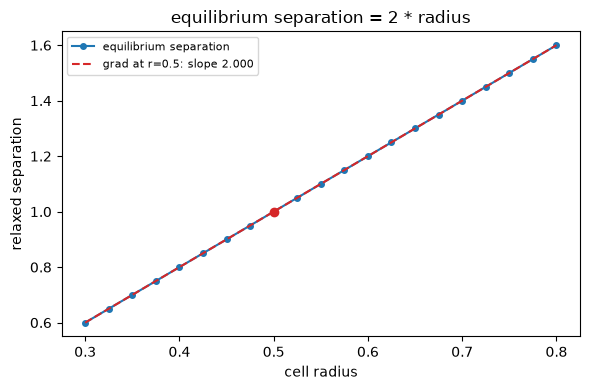

In [8]:
relax2 = MechanicalRelaxation(Morse(), max_steps=1500, f_tol=1e-9)


def separation(radius):
    s = make_state(jxm.Model([relax2]), jnp.array([[0.0, 0.0], [1.0, 0.0]]), radius=radius)
    s2 = relax2(s, dt=1.0, key=None)
    return jnp.linalg.norm(s2.position[0] - s2.position[1])


radii = np.linspace(0.3, 0.8, 21)
seps = np.array([float(separation(r)) for r in radii])

r0 = 0.5
g = float(jax.grad(separation)(r0))  # implicit-function-theorem gradient through the equilibrium
s0_val = float(separation(r0))
print('d(separation)/d(radius) via implicit diff:', g, '   (analytic: 2.0)')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(radii, seps, 'o-', ms=4, label='equilibrium separation')
tang = s0_val + g * (radii - r0)
ax.plot(radii, tang, '--', color='tab:red', label=f'grad at r=0.5: slope {g:.3f}')
ax.scatter([r0], [s0_val], color='tab:red', zorder=5)
ax.set(xlabel='cell radius', ylabel='relaxed separation', title='equilibrium separation = 2 * radius')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 3. Brownian dynamics

`BrownianDynamics` is a **dynamic, stochastic** step: one Euler-Maruyama step of overdamped Langevin
dynamics,

```
dx = dt * (-grad U / gamma) + sqrt(2 kT dt / gamma) * xi,   xi ~ N(0, I)
```

a deterministic drift down the potential plus Gaussian noise. `simulate` scans it to physical time.
First, a **free-diffusion** check: far-apart cells (no force) should spread as `MSD(t) = 2 d D t`
with the Einstein diffusivity `D = kT / gamma`. We run 300 non-interacting cells and average.

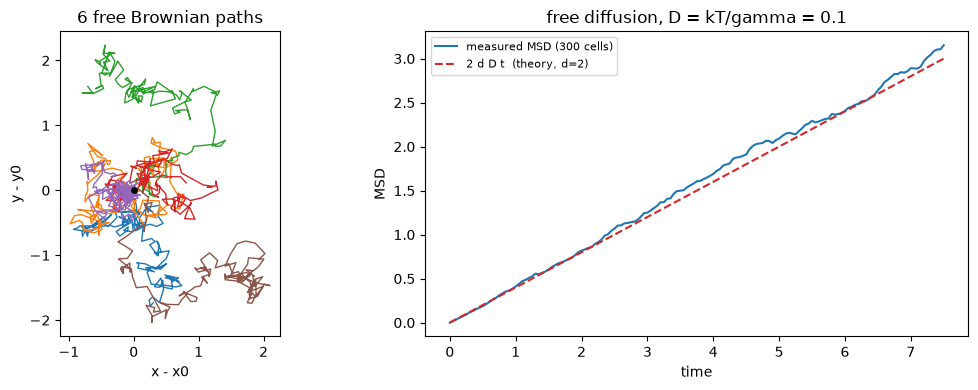

In [9]:
pot = Morse()
gamma, kT = 1.0, 0.1
D = kT / gamma
bd = BrownianDynamics(pot, n_space_dim=2, gamma=gamma, kT=kT)
model = jxm.Model([bd])

# 300 cells on a wide grid (spacing 50 >> cutoff): they never interact -> pure free diffusion.
side = 20
xs, ys = np.meshgrid(np.arange(side), np.arange(side))
grid = 50.0 * np.stack([xs.ravel(), ys.ravel()], axis=1)[:300].astype(float)
s_free = make_state(model, grid, radius=0.5)

dt, n_steps = 0.05, 150
traj = jxm.simulate(model, s_free, n_steps=n_steps, dt=dt, key=key, history=True)

pos0 = np.asarray(s_free.position)
posT = np.asarray(traj.position)                       # (n_steps + 1, n_cells, 2)
msd = ((posT - pos0[None]) ** 2).sum(-1).mean(1)       # includes the zero-displacement initial frame
t = np.asarray(traj.t)

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4))
for i in range(6):  # a handful of individual Brownian paths (recentred to their start)
    p = posT[:, i, :] - pos0[i]
    a0.plot(p[:, 0], p[:, 1], lw=1)
a0.scatter([0], [0], color='k', s=15, zorder=5)
a0.set_aspect('equal')
a0.set(xlabel='x - x0', ylabel='y - y0', title='6 free Brownian paths')

a1.plot(t, msd, label='measured MSD (300 cells)')
a1.plot(t, 2 * 2 * D * t, '--', color='tab:red', label='2 d D t  (theory, d=2)')
a1.set(xlabel='time', ylabel='MSD', title=f'free diffusion, D = kT/gamma = {D:g}')
a1.legend(fontsize=8)
fig.tight_layout()
plt.show()

### Scoring a transition: the score-function gradient

Brownian is a `StochasticStep`, so a transition `(s_t, s_{t+1})` can be **scored**:
`transition_logp` is the Gaussian log-density of the recorded displacement under the transition kernel,
with parameters recomputed live. That makes `kT`, `gamma`, and the potential's parameters learnable
from observed motion (MLE). A reparameterized step defaults to the pathwise estimator (next section),
so we opt into scoring it explicitly with `score='all'`. We take one recorded transition of an interacting pair, then sweep `kT`
in the scorer: the log-density peaks at the `kT` that best explains the displacement, and `jax.grad`
gives the exact score at any point.

d logp / d kT at kT=0.05: 56.11847116902588


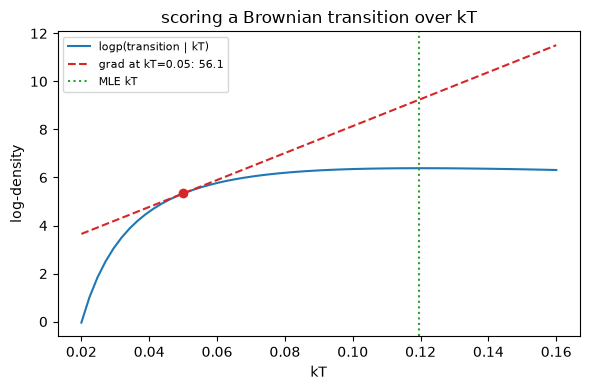

In [10]:
pair = make_state(jxm.Model([BrownianDynamics(pot, n_space_dim=2, kT=0.05)]),
                  jnp.array([[0.0, 0.0], [1.2, 0.0]]), radius=0.5)
m_sample = jxm.Model([BrownianDynamics(pot, n_space_dim=2, gamma=1.0, kT=0.05)])
pair_next = m_sample(pair, dt=0.01, key=key)  # sample + record the displacement into the trace


@jax.jit
def logp_of_kT(kt):  # kt a traced 0-d array -> compiled once, reused across the sweep
    m = jxm.Model([BrownianDynamics(pot, n_space_dim=2, gamma=1.0, kT=kt)])
    return jxm.transition_logp(m, pair, pair_next, 0.01, score='all')  # opt in: Brownian is pathwise by default


grad_logp = jax.jit(jax.grad(logp_of_kT))

kts = np.linspace(0.02, 0.16, 60)
lps = np.array([float(logp_of_kT(jnp.array(k))) for k in kts])

k0 = 0.05
g0 = float(grad_logp(jnp.array(k0)))
l0 = float(logp_of_kT(jnp.array(k0)))
print('d logp / d kT at kT=0.05:', g0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(kts, lps, label='logp(transition | kT)')
ax.plot(kts, l0 + g0 * (kts - k0), '--', color='tab:red', label=f'grad at kT=0.05: {g0:.1f}')
ax.axvline(kts[np.argmax(lps)], color='tab:green', ls=':', label='MLE kT')
ax.scatter([k0], [l0], color='tab:red', zorder=5)
ax.set(xlabel='kT', ylabel='log-density', title='scoring a Brownian transition over kT')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### The other estimator: a pathwise gradient through `simulate`

Because the noise is *reparameterized* (`dx = mean + std * xi` with `xi` frozen), the forward rollout
is also **pathwise**-differentiable: we can differentiate a whole simulated trajectory with respect to
`kT` directly, no scoring involved. Here the objective is the mean squared displacement of a free
cloud after several steps; its value grows linearly with `kT` (variance scales with `kT`) and
`jax.grad` returns the matching slope.

pathwise d(spread) / d(kT) at kT=0.1: 3.841777859207043


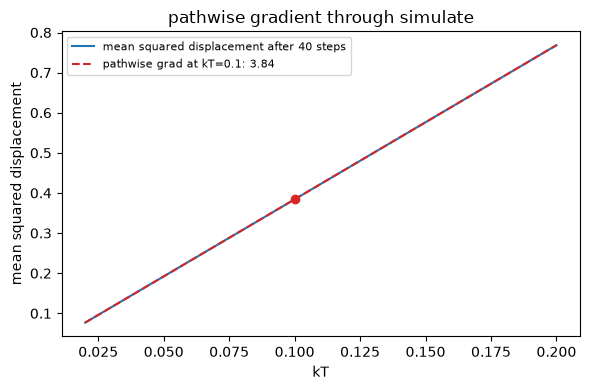

In [11]:
cloud = make_state(model, 50.0 * np.stack(np.meshgrid(np.arange(8), np.arange(8)), -1).reshape(-1, 2),
                   radius=0.5)


@jax.jit
def spread(kt):
    m = jxm.Model([BrownianDynamics(pot, n_space_dim=2, gamma=1.0, kT=kt)])
    final = jxm.simulate(m, cloud, n_steps=40, dt=0.02, key=key)
    a = cloud.alive.astype(final.position.dtype)[:, None]
    disp2 = ((final.position - cloud.position) ** 2 * a).sum()
    return disp2 / a.sum()


grad_spread = jax.jit(jax.grad(spread))

kts = np.linspace(0.02, 0.2, 60)
vals = np.array([float(spread(jnp.array(k))) for k in kts])
k0 = 0.1
g0 = float(grad_spread(jnp.array(k0)))
v0 = float(spread(jnp.array(k0)))
print('pathwise d(spread) / d(kT) at kT=0.1:', g0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(kts, vals, label='mean squared displacement after 40 steps')
ax.plot(kts, v0 + g0 * (kts - k0), '--', color='tab:red', label=f'pathwise grad at kT=0.1: {g0:.2f}')
ax.scatter([k0], [v0], color='tab:red', zorder=5)
ax.set(xlabel='kT', ylabel='mean squared displacement', title='pathwise gradient through simulate')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### Drift + noise: aggregation

Put the two ingredients together at low temperature: the Morse **drift** pulls neighbours within the
cutoff into contact while the **noise** lets the cluster rearrange. Starting from cells scattered
across a few interaction lengths, a Brownian rollout condenses them into a packed aggregate.

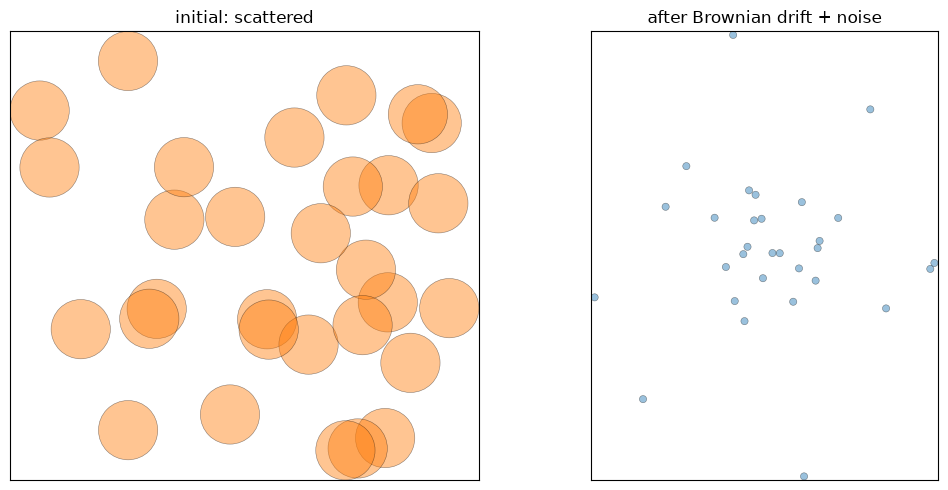

In [12]:
bd_cold = BrownianDynamics(Morse(), n_space_dim=2, gamma=1.0, kT=0.02)
model_cold = jxm.Model([bd_cold])

n = 30
start = jax.random.uniform(jax.random.PRNGKey(7), (n, 2), minval=0.0, maxval=7.0)
s_start = make_state(model_cold, start, radius=0.5)
s_end = jxm.simulate(model_cold, s_start, n_steps=600, dt=0.02, key=jax.random.PRNGKey(8))

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 5))
jxm.viz.draw(s_start, ax=a0, color='tab:orange', alpha=0.45, title='initial: scattered')
jxm.viz.draw(s_end, ax=a1, color='tab:blue', alpha=0.45, title='after Brownian drift + noise')
fig.tight_layout()
plt.show()

## 4. Virial stress (a per-cell sensing input)

`VirialStress` is a *quasistatic* step that writes each cell's virial pressure (from
`PairwisePotential.virial_pressure`) into a `stress` field - a mechanical-load signal a control step
can read. We compress a packed disk of cells (grid spacing `0.75`, well inside the contact distance
`sigma = 1.0`, so every cell is squeezed by its nearest neighbours) and colour each cell by its
stress. The peak is **not** at the centre but in a **sub-surface ring**: every interior cell shares
the same compressed nearest-neighbour core (the same positive, compressive contribution), but the
*attractive* outer shell - which pulls the net pressure back **down** - is complete only deep in the
bulk. A cell one shell below the free surface has lost part of that attractive shell, so it carries
*more* pressure than the fully-embedded centre; the outermost cells then drop off as they shed
compressed neighbours too.

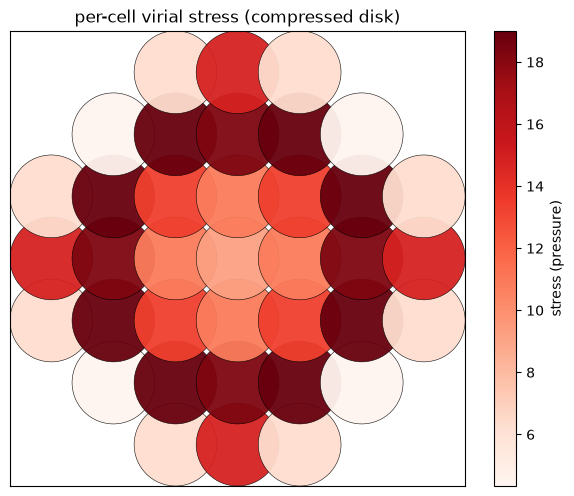

stress: centre +9.25  |  peak ring (r=1.68) +19.01  |  outer edge +6.34   (compression -> positive)


In [13]:
spacing = 0.75
g = np.arange(-4, 5) * spacing
gx, gy = np.meshgrid(g, g)
pts = np.stack([gx.ravel(), gy.ravel()], axis=1)
pts = pts[np.linalg.norm(pts, axis=1) <= 3.6 * spacing]  # keep a rough disk

vs_model = jxm.Model([VirialStress(Morse())])
s_stress = vs_model(make_state(vs_model, pts, radius=0.5), dt=1.0, key=key)  # writes .stress

fig, ax = plt.subplots(figsize=(6, 5))
jxm.viz.draw(s_stress, ax=ax, color_by=s_stress.stress, cmap='Reds', alpha=0.95,
             title='per-cell virial stress (compressed disk)')
fig.axes[-1].set_ylabel('stress (pressure)')
fig.tight_layout()
plt.show()

# the maximum is a sub-surface ring, not the centre: same compressed core, but a thinner attractive
# shell (fewer outer neighbours pulling the pressure back down) than the fully-embedded centre cell.
radial = np.linalg.norm(pts, axis=1)
stress = np.asarray(s_stress.stress)
center_i, peak_i, edge_i = int(np.argmin(radial)), int(np.argmax(stress)), int(np.argmax(radial))
print(f'stress: centre {stress[center_i]:+.2f}'
      f'  |  peak ring (r={radial[peak_i]:.2f}) {stress[peak_i]:+.2f}'
      f'  |  outer edge {stress[edge_i]:+.2f}   (compression -> positive)')

## 5. Saturating cell growth

`SaturatingCellGrowth` is a *dynamic* step with a saturating (von Bertalanffy) law
`dr/dt = growth_rate * (1 - r / max_radius)`, integrated exactly (not forward Euler) so it stays
stable for any `dt`. The
rate is a **per-cell state field** (`growth_rate`), not a module parameter - so it can be a fixed
initial condition or, in a full model, an upstream controller's output. Each cell approaches the
shared `max_radius`, faster or slower according to its own rate.

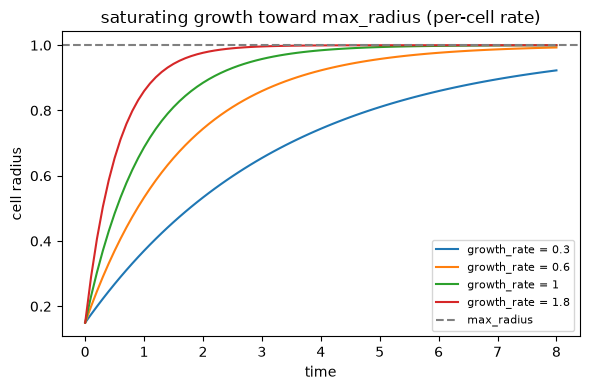

In [14]:
model = jxm.Model([SaturatingCellGrowth(max_radius=1.0)])
State = jxm.build_state_from_model(model)
rates = [0.3, 0.6, 1.0, 1.8]

s = State.init_empty(capacity=len(rates), n_space_dim=2, n_types=1)
s = s.update(
    alive=s.alive.at[:].set(True),
    radius=s.radius.at[:].set(0.15),
    growth_rate=s.growth_rate.at[:].set(jnp.array(rates)),
    celltype=s.celltype.at[:, 0].set(1.0),
)

n_steps, dt = 80, 0.1
traj = jxm.simulate(model, s, n_steps=n_steps, dt=dt, history=True)  # deterministic: no key
radii = np.asarray(traj.radius)
t = np.asarray(traj.t)

fig, ax = plt.subplots(figsize=(6, 4))
for i, rate in enumerate(rates):
    ax.plot(t, radii[:, i], label=f'growth_rate = {rate:g}')
ax.axhline(1.0, color='0.5', ls='--', label='max_radius')
ax.set(xlabel='time', ylabel='cell radius', title='saturating growth toward max_radius (per-cell rate)')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### The gradient flows through the per-cell rate

Because the rate lives in the state, the whole rollout is differentiable with respect to it: a
morphology objective (here the final radius after a fixed time) has a well-defined gradient
`d(final radius) / d(growth_rate)`. This is exactly what lets an upstream controller that *writes*
`growth_rate` be trained by backpropagating through growth. We sweep the rate and overlay the
pathwise gradient `jax.grad` returns.

d(final radius) / d(growth_rate) at rate=1.0: 0.12695702433805273


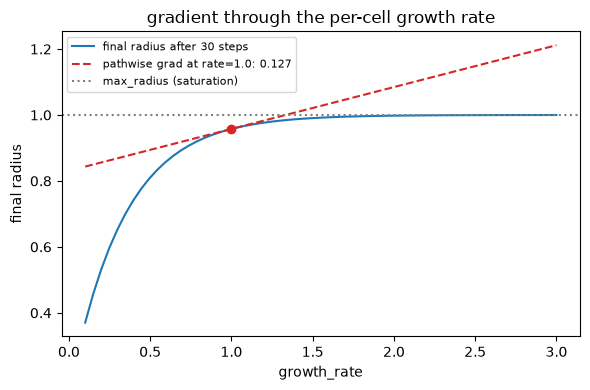

In [15]:
model = jxm.Model([SaturatingCellGrowth(max_radius=1.0)])
State = jxm.build_state_from_model(model)


@jax.jit
def final_radius(rate0):
    s = State.init_empty(capacity=1, n_space_dim=2, n_types=1)
    s = s.update(
        alive=s.alive.at[0].set(True),
        radius=s.radius.at[0].set(0.15),
        growth_rate=s.growth_rate.at[0].set(rate0),
    )
    return jxm.simulate(model, s, n_steps=30, dt=0.1).radius[0]


grad_final = jax.jit(jax.grad(final_radius))
rates = np.linspace(0.1, 3.0, 60)
vals = np.array([float(final_radius(jnp.array(r))) for r in rates])

r0 = 1.0
g0 = float(grad_final(jnp.array(r0)))
v0 = float(final_radius(jnp.array(r0)))
print('d(final radius) / d(growth_rate) at rate=1.0:', g0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(rates, vals, label='final radius after 30 steps')
ax.plot(rates, v0 + g0 * (rates - r0), '--', color='tab:red', label=f'pathwise grad at rate=1.0: {g0:.3f}')
ax.axhline(1.0, color='0.5', ls=':', label='max_radius (saturation)')
ax.scatter([r0], [v0], color='tab:red', zorder=5)
ax.set(xlabel='growth_rate', ylabel='final radius', title='gradient through the per-cell growth rate')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 6. Putting it together: a growing, relaxing cluster

The steps compose. A model of `MechanicalRelaxation` (quasistatic, on positions) **and**
`SaturatingCellGrowth` (dynamic, on radii) writes disjoint fields, so each macro-step relaxes the
packing at the current
sizes and then grows the cells a little. As the radii grow, the contact distance `sigma = r_i + r_j`
grows with them, so the relaxed cluster **expands** while staying mechanically packed.

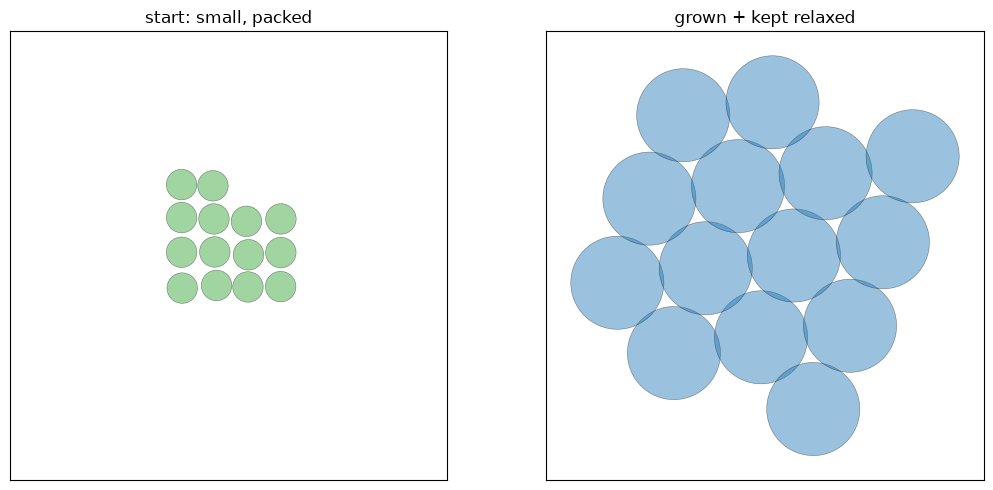

mean radius: 0.250 -> 0.763 | cluster expands as the cells grow while staying in contact


In [16]:
pot = Morse()
model = jxm.Model(
    [MechanicalRelaxation(pot, max_steps=500, f_tol=1e-6), SaturatingCellGrowth(max_radius=0.9)]
)
State = jxm.build_state_from_model(model)

# A small, compact cluster of 14 cells on a lightly jittered grid (spacing 0.55 ~ contact for
# radius 0.25), so every cell is within the Morse range and the first relaxation packs it cleanly.
n = 14
gx, gy = np.meshgrid(np.arange(4), np.arange(4))
grid = 0.55 * np.stack([gx.ravel(), gy.ravel()], axis=1).astype(float)[:n]
grid = grid - grid.mean(0)
start = grid + 0.02 * np.asarray(jax.random.normal(jax.random.PRNGKey(5), (n, 2)))

s = State.init_empty(capacity=n, n_space_dim=2, n_types=1)
s = s.update(
    alive=s.alive.at[:].set(True),
    radius=s.radius.at[:].set(0.25),
    growth_rate=s.growth_rate.at[:].set(1.0),
    celltype=s.celltype.at[:, 0].set(1.0),
    position=s.position.at[:].set(start),
)
s_end = jxm.simulate(model, s, n_steps=14, dt=0.1)  # deterministic: relax + grow each macro-step

# Share the grown cluster's (larger) limits across both panels so the start really looks small.
xlim, ylim = shared_limits(s_end)

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 5))
jxm.viz.draw(s, ax=a0, color='tab:green', alpha=0.45, lims=(xlim, ylim), title='start: small, packed')
jxm.viz.draw(s_end, ax=a1, color='tab:blue', alpha=0.45, lims=(xlim, ylim),
             title='grown + kept relaxed')
fig.tight_layout()
plt.show()

print('mean radius:', f'{float(s.radius.mean()):.3f} -> {float(s_end.radius.mean()):.3f}',
      '| cluster expands as the cells grow while staying in contact')